# explore data

In [4]:
import csv

file_path = "../data/nvda_us.csv"

with open(file_path, 'r', newline='', encoding='utf-8') as file:
    reader = csv.reader(file)
    row_count = sum(1 for row in reader)
    
print(f"number of data points:{row_count}")

number of data points:6722


- should be roughly that number of trading days between jan 22 1999 and oct 10 2025
- looks good

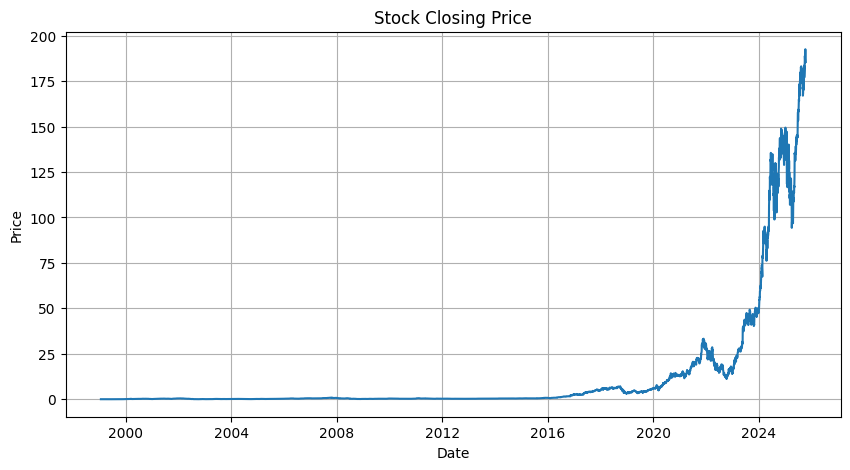

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV data into a pandas DataFrame
# Replace 'your_stock_data.csv' with your actual filename
df = pd.read_csv('../data/nvda_us.csv')

# Convert the 'Date' column to a proper datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Plot the closing price against the date
plt.figure(figsize=(10, 5))
plt.plot(df['Date'], df['Close'])
plt.title('Stock Closing Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()

- graph of the closing price since listing
    - if only I'd bought a bunch in 2016

## found a good source, additional data will make this better

In [9]:
import pandas as pd
from dotenv import load_dotenv
import os

load_dotenv()

# create file dicttionary
files = {
    'NVDA': os.getenv('NVDA'),
    'NDX': os.getenv('NDX'),
    'SPX': os.getenv('SPX'),
    'VIX': os.getenv('VIX')
}

# use NVDA as base
df_master = pd.read_csv(files['NVDA'], parse_dates=['Date'])

# rename columns appropriately
df_master = df_master.rename(columns={
    'Open': 'Open_NVDA',
    'High': 'High_NVDA',
    'Low': 'Low_NVDA',
    'Close': 'Close_NVDA',
    'Volume': 'Volume_NVDA'
})

# merge other data
for name, path in list(files.items())[1:]:
    # load the next file
    df_temp = pd.read_csv(path, parse_dates=['Date'])

    # column names
    df_temp = df_temp.rename(columns={
        'Open': f'Open_{name}',
        'High': f'High_{name}',
        'Low': f'Low_{name}',
        'Close': f'Close_{name}',
        'Volume': f'Volume_{name}'
    })
    
    # only merge date and new column
    columns_to_merge = ['Date'] + [col for col in df_temp.columns if col != 'Date']

    # makes sure to only keep dates that are shared
    df_master = pd.merge(df_master, df_temp[columns_to_merge], on='Date', how='inner')

# save merged .csv
df_master.to_csv('final_aligned_data.csv', index=False)

print(f"merged dataset has {len(df_master)} rows")
print("saved to final_aligned_data.csv")
print(df_master.tail())

merged dataset has 6717 rows
saved to final_aligned_data.csv
           Date  Open_NVDA  High_NVDA  Low_NVDA  Close_NVDA  Volume_NVDA  \
6712 2025-10-03    189.190     190.36    185.38      187.62    137596896   
6713 2025-10-06    185.500     187.23    183.33      185.54    157678104   
6714 2025-10-07    186.230     189.06    184.00      185.04    140088008   
6715 2025-10-08    186.570     189.60    186.54      189.11    130168861   
6716 2025-10-09    192.225     195.30    191.06      192.57    182997234   

      Open_NDX  High_NDX   Low_NDX  Close_NDX    Volume_NDX  Open_SPX  \
6712  24931.42  24958.26  24713.58   24785.52  1.041512e+09   6722.14   
6713  24986.26  25044.26  24907.60   24978.56  1.287839e+09   6733.86   
6714  25031.78  25062.96  24783.95   24840.23  1.070088e+09   6746.14   
6715  24887.32  25142.19  24882.35   25136.62  1.090958e+09   6723.87   
6716  25124.79  25139.35  24966.81   25098.18  1.025642e+09   6760.50   

      High_SPX  Low_SPX  Close_SPX    Volum

- merged data sources for training